# Prediction with a pre-trained model (PyTorch)

## ✅ Environment / Kernel (Run this first)
- **Kernel to select in VS Code:** `Python 3.13.10 (.venv/bin/python)`
- **Run from terminal with `uv` (no manual activation):**
  ```bash
  cd /home/roderickperez/DataScienceProjects/multiTaskLearningSeismic
  uv run jupyter lab
  ```

In [ ]:
import sys
import importlib

print("Python executable:", sys.executable)

for module_name in ["tensorflow", "keras", "torch"]:
    try:
        module = importlib.import_module(module_name)
        print(f"{module_name}: {module.__version__}")
    except Exception as error:
        print(f"{module_name}: not available ({error})")

try:
    import tensorflow as tf
    print("TF GPUs:", tf.config.list_physical_devices("GPU"))
except Exception as error:
    print("TF GPU check failed:", error)

try:
    import torch
    print("Torch CUDA:", torch.cuda.is_available(), "devices:", torch.cuda.device_count())
except Exception as error:
    print("Torch CUDA check failed:", error)

This notebook demonstrates how to use a pre-trained 3D U-Net model to perform fault segmentation on new seismic data. It covers two scenarios:
1.  **Simple Prediction:** Running inference on a single data cube (e.g., from the validation set) to quickly check model performance.
2.  **Complex Prediction:** Running inference on a large field data volume that is bigger than the model's input size. This requires a tiling (or patching) approach with overlapping and blending to produce a smooth, final result.

## Step 1: Import Libraries and Configure Environment

First, we import the necessary libraries and configure the GPU. This setup is identical to our training notebook to ensure consistency.

In [1]:
import os, sys, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from unet3_pytorch import unet


Check for GPU availability and configure it

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

## Step 2: Define Paths and Parameters

Here we define the paths to our data and the trained model. **Make sure `MODEL_NAME` points to the specific model file you want to use for prediction.**

In [2]:
try:                                   # for .py scripts
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:                      # for Jupyter notebooks
    ROOT_DIR = os.getcwd()

In [3]:
# Step 2: Define Paths and Parameters
# --- Data Paths ---
BASE_DIR = ROOT_DIR

ORIG_DATA_DIR = os.path.join(BASE_DIR, "data")
VAL_DIR       = os.path.join(ORIG_DATA_DIR, "validation_npy")
MODEL_DIR     = os.path.join(BASE_DIR, "model")

# --- Model Paths ---------------------------------------------------
# Automatically pick the newest .pth checkpoint
pth_ckpts = sorted(
    [f for f in os.listdir(MODEL_DIR) if f.endswith(".pth")],
    key=lambda x: os.path.getmtime(os.path.join(MODEL_DIR, x))
)
if not pth_ckpts:
    raise FileNotFoundError(f"No .pth checkpoints found in {MODEL_DIR}")

MODEL_NAME = pth_ckpts[-1]
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)
print("Will load model:", MODEL_NAME)

# F3D_DIR logic to match Keras but keep robustness
F3D_DIR = os.path.join(ROOT_DIR, "..", "data", "data_from_Wu", "prediction", "f3d")
F3D_DIR = os.path.abspath(F3D_DIR)

if not os.path.exists(os.path.join(F3D_DIR, "gxl.dat")):
     # Fallback to internal data structure if external fails
    print(f"WARNING: gxl.dat not found in {F3D_DIR}, checking local data folder...")
    F3D_DIR = os.path.join(BASE_DIR, "data", "data_from_Wu", "fp", "f3d")

# --- Model Input Parameters ---------------------------------------
PATCH_N1 = PATCH_N2 = PATCH_N3 = 128
OVERLAP = 12


Will load model: unet_pytorch_model_200pairs_25epochs_2025-11-29_09-48-46.pth


## Step 3: Load the Trained Model

We load the compiled model from the specified file.

In [4]:
# Step 3: Load the Trained PyTorch model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

print("Loading model:", MODEL_PATH)
model = unet(input_size=(PATCH_N1, PATCH_N2, PATCH_N3), pretrained_weights=None)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print("Model loaded & eval mode set.")


Device: NVIDIA RTX A5000
Loading model: /home/roderickperez/DS_PROJECTS/faultSeg/faultSeg_2019_pyTorch/model/unet_pytorch_model_200pairs_25epochs_2025-11-29_09-48-46.pth


/tmp/ipykernel_13385/3098725798.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


Model loaded & eval mode set.


## Step 4: Simple Prediction on a Validation Sample

This is a sanity check to ensure the model loads and predicts correctly. We take one sample from the validation set, apply the same preprocessing as in training, and visualize the result.

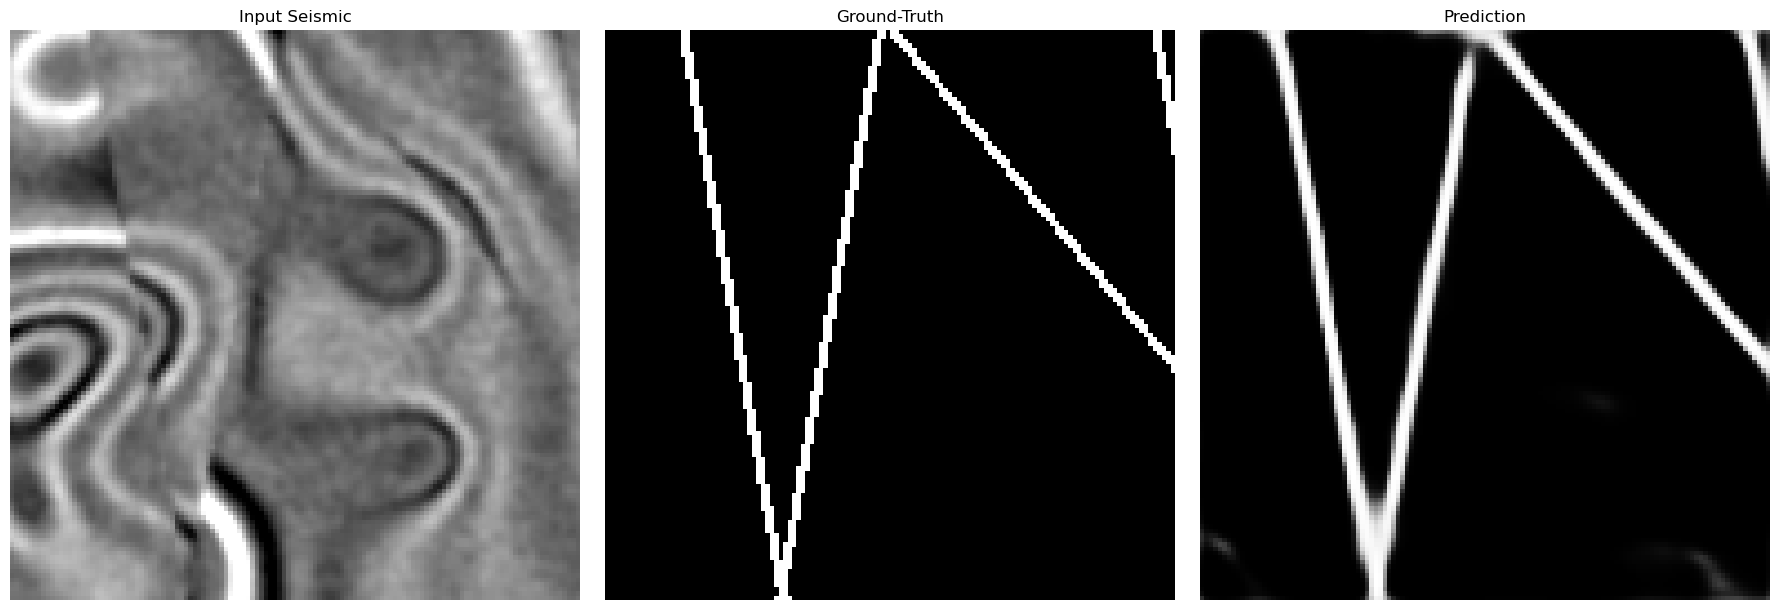

Saved combined image to /home/roderickperez/DS_PROJECTS/faultSeg/faultSeg_2019_pyTorch/output/images/prediction_slice_64.png


In [5]:
# Step 4: Simple Prediction on a Validation Sample
# This is a sanity check to ensure the model loads and predicts correctly.

SAMPLE_ID = "10"
gx = np.load(os.path.join(VAL_DIR, "seis",  f"{SAMPLE_ID}.npy"))
fx = np.load(os.path.join(VAL_DIR, "fault", f"{SAMPLE_ID}.npy"))

gx_norm = (gx - gx.mean()) / (gx.std() + 1e-8)
gx_tr   = np.transpose(gx_norm)
fx_tr   = np.transpose(fx)

input_tensor = torch.from_numpy(gx_tr).unsqueeze(0).unsqueeze(0).to(device, dtype=torch.float)
with torch.no_grad():
    fp_tensor = model(input_tensor)
fp_tr = fp_tensor.squeeze().cpu().numpy()

SLICE = 64

# Visualization
output_dir = os.path.join(BASE_DIR, "output", "images")
os.makedirs(output_dir, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].set_title("Input Seismic")
axes[0].imshow(gx_tr[SLICE].T, cmap='gray', vmin=-2, vmax=2)
axes[0].axis('off')

axes[1].set_title("Ground-Truth")
axes[1].imshow(fx_tr[SLICE].T, cmap='gray', vmin=0, vmax=1)
axes[1].axis('off')

axes[2].set_title("Prediction")
axes[2].imshow(fp_tr[SLICE].T, cmap='gray', vmin=0, vmax=1)
axes[2].axis('off')

plt.tight_layout()
save_path = os.path.join(output_dir, f"prediction_slice_{SLICE}.png")
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Saved combined image to {save_path}")


## Step 5: Complex Prediction on a Large Field Image (Tiling/Patching)

Real-world seismic volumes are much larger than the model's `128x128x128` input size. To handle this, we use a patch-based approach:
1.  **Padding:** The large volume is padded with zeros to ensure it's perfectly divisible by our patch-and-stride logic.
2.  **Tiling:** We slide a `128x128x128` window across the padded volume with a defined overlap.
3.  **Blending:** To avoid sharp edges in the final prediction, we use a Gaussian mask. Predictions in the center of a patch have a higher weight than those at the edges.
4.  **Stitching:** We accumulate the weighted predictions and the weights themselves. The final fault probability at each point is the sum of weighted predictions divided by the sum of weights.

In [6]:
# Step 5: Complex Prediction on a Large Field Image (Tiling/Patching)

def create_gaussian_mask(overlap, shape1, shape2, shape3):
    # Create 1D Gaussian window (actually linear ramp as per Keras notebook)
    def get_window(size, overlap):
        w = np.ones(size)
        w[:overlap] = np.linspace(0, 1, overlap)
        w[-overlap:] = np.linspace(1, 0, overlap)
        return w

    # Create 3D mask
    w1 = get_window(shape1, overlap)
    w2 = get_window(shape2, overlap)
    w3 = get_window(shape3, overlap)
    
    mask = np.einsum('i,j,k->ijk', w1, w2, w3)
    return mask


In [7]:
f3d_path = os.path.join(F3D_DIR, 'gxl.dat')
if not os.path.exists(f3d_path):
    print(f'WARNING: Large volume file not found at {f3d_path}. Skipping tiling prediction.')
else:
    m3, m2, m1 = 512, 384, 128
    gx = np.fromfile(f3d_path, dtype=np.single).reshape(m3, m2, m1)
    print(f"Loaded F3 field data with shape: {gx.shape}")
    
    # Transpose to (128, 384, 512) to match the processing orientation
    gx = np.transpose(gx)
    m1, m2, m3 = gx.shape
    print(f"Transposed shape for processing: {gx.shape}")
    
    # --- 3. Setup Tiling Parameters ---
    overlap_size = OVERLAP
    stride = (PATCH_N1 - overlap_size, PATCH_N2 - overlap_size, PATCH_N3 - overlap_size)
    
    # Calculate padding
    p1 = (stride[0] - (m1 - PATCH_N1) % stride[0]) % stride[0]
    p2 = (stride[1] - (m2 - PATCH_N2) % stride[1]) % stride[1]
    p3 = (stride[2] - (m3 - PATCH_N3) % stride[2]) % stride[2]
    gp = np.pad(gx, ((0,p1), (0,p2), (0,p3)), mode='constant', constant_values=0)
    padded_shape = gp.shape
    print(f"Padded shape: {padded_shape}")
    
    # --- 4. Initialize Output and Run Prediction Loop ---
    gy = np.zeros(padded_shape, dtype=np.single)
    mk = np.zeros(padded_shape, dtype=np.single)
    sc = create_gaussian_mask(overlap_size, PATCH_N1, PATCH_N2, PATCH_N3)
    
    k1_range = range(0, padded_shape[0] - PATCH_N1 + 1, stride[0])
    k2_range = range(0, padded_shape[1] - PATCH_N2 + 1, stride[1])
    k3_range = range(0, padded_shape[2] - PATCH_N3 + 1, stride[2])
    
    print("Starting tiling prediction on large volume...")
    for k1 in tqdm(k1_range, desc="Dim 1"):
        for k2 in k2_range:
            for k3 in k3_range:
                patch = gp[k1:k1+PATCH_N1, k2:k2+PATCH_N2, k3:k3+PATCH_N3]
                # Preprocessing: Standardization
                patch_processed = (patch - np.mean(patch)) / (np.std(patch) + 1e-8)
                
                input_patch = torch.from_numpy(patch_processed).unsqueeze(0).unsqueeze(0).to(device, dtype=torch.float)
                with torch.no_grad():
                    predicted_patch_tensor = model(input_patch)
                
                predicted_patch = predicted_patch_tensor.squeeze().cpu().numpy()
                
                # Accumulate with Gaussian blending
                gy[k1:k1+PATCH_N1, k2:k2+PATCH_N2, k3:k3+PATCH_N3] += predicted_patch * sc
                mk[k1:k1+PATCH_N1, k2:k2+PATCH_N2, k3:k3+PATCH_N3] += sc
    
    # --- 5. Finalize by Averaging and Cropping ---
    gy = np.divide(gy, mk, out=np.zeros_like(gy), where=mk!=0)
    fp_final = gy[:m1, :m2, :m3]
    
    print(f"Prediction complete. Final fault probability map shape: {fp_final.shape}")
    
    # Save the result
    output_filename = os.path.join(F3D_DIR, "fp_pytorch.dat")
    fp_final.astype(np.single).tofile(output_filename)
    
    print(f"Final prediction saved to: {output_filename}")


Loaded F3 field data with shape: (512, 384, 128)
Transposed shape for processing: (128, 384, 512)
Padded shape: (128, 476, 592)
Starting tiling prediction on large volume...


Dim 1:   0%|          | 0/1 [00:00<?, ?it/s]

Prediction complete. Final fault probability map shape: (128, 384, 512)
Final prediction saved to: /home/roderickperez/DS_PROJECTS/faultSeg/data/data_from_Wu/prediction/f3d/fp_pytorch.dat


/tmp/ipykernel_13385/280950731.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


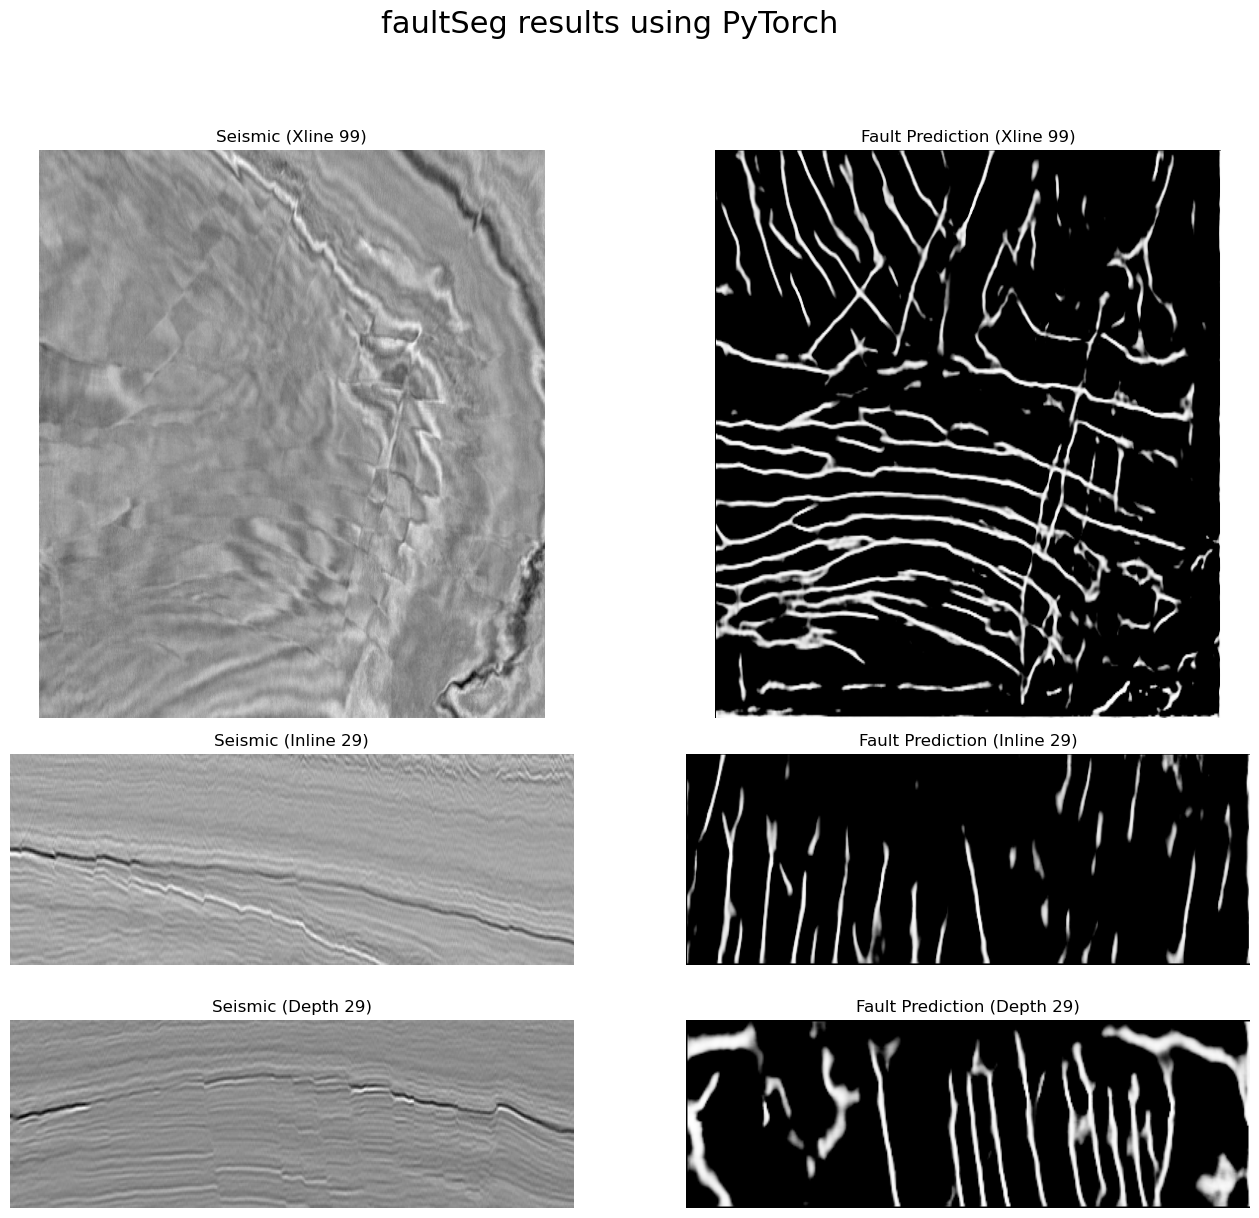

faultSeg results using PyTorch /home/roderickperez/DS_PROJECTS/faultSeg/faultSeg_2019_pyTorch/output/images/faultSegResultsUsingPyTorch.png


In [12]:
output_dir = os.path.join(ROOT_DIR, "output", "images")
os.makedirs(output_dir, exist_ok=True)
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 14),                      # a bit shorter overall
    gridspec_kw=dict(
        height_ratios=[1, 0.4, 0.4],       # <-- key change
        hspace=0.08                        # tiny gap
    )
)
fig.suptitle("faultSeg results using PyTorch", fontsize=22)
# Xline Slice
gx_xline = gx_orig_view[:, :, k3_xline]
fp_xline = fp_orig_view[:, :, k3_xline]
axes[0, 0].set_title(f"Seismic (Xline {k3_xline})")
axes[0, 0].imshow(np.transpose(gx_xline), aspect=1.5, cmap=plt.cm.gray)
axes[0, 0].axis('off')
axes[0, 1].set_title(f"Fault Prediction (Xline {k3_xline})")
axes[0, 1].imshow(np.transpose(fp_xline), aspect=1.5, interpolation="bilinear", vmin=0.4, vmax=1.0, cmap=plt.cm.gray)
axes[0, 1].axis('off')

# Inline Slice
gx_inline = gx_orig_view[:, k2_inline, :]
fp_inline = fp_orig_view[:, k2_inline, :]
axes[1, 0].set_title(f"Seismic (Inline {k2_inline})")
axes[1, 0].imshow(np.transpose(gx_inline), aspect=1.5, cmap=plt.cm.gray)
axes[1, 0].axis('off')
axes[1, 1].set_title(f"Fault Prediction (Inline {k2_inline})")
axes[1, 1].imshow(np.transpose(fp_inline), aspect=1.5, interpolation="bilinear", vmin=0.4, vmax=1.0, cmap=plt.cm.gray)
axes[1, 1].axis('off')

# Depth Slice
gx_depth = gx_orig_view[k1_depth, :, :]
fp_depth = fp_orig_view[k1_depth, :, :]
axes[2, 0].set_title(f"Seismic (Depth {k1_depth})")
axes[2, 0].imshow(np.transpose(gx_depth), cmap=plt.cm.gray)
axes[2, 0].axis('off')
axes[2, 1].set_title(f"Fault Prediction (Depth {k1_depth})")
axes[2, 1].imshow(np.transpose(fp_depth), interpolation="bilinear", vmin=0.4, vmax=1.0, cmap=plt.cm.gray)
axes[2, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])

save_path = os.path.join(output_dir, "faultSegResultsUsingPyTorch.png")
plt.savefig(save_path)
plt.show()
print(f"faultSeg results using PyTorch {save_path}")